# Notebook 1: Data Loading & Merging
**Course:** Economic and Social Statistics (AST3336) — Year 3, Semester 2
**Institution:** University of Rwanda, College of Business and Economics
**Group:** Group 1 — AHS 2024: Poverty & Demographics
**Dataset:** Rwanda Agricultural Household Survey (AHS) 2024
**Reference ID:** RWA-NISR-RAHS-2024-V0.1

---

## Objective
1. Load Section 0, Section 1, Section 2 from raw Stata files
2. Collapse Section 1 (individual level) to household level
3. Collapse Section 2 (plot level) to household level
4. Merge all three into one clean analytical dataset
5. Save as `data/ahs2024_merged.csv`

**Merge key:** `hhid`

## 1. Import Libraries

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Define Paths

In [84]:
RAW = r"C:\Users\user\Desktop\Academic\Y3\CBE 2024-2025\Economic and Social Statistics\2026\Microdata\Microdata"
OUT = r"..\data"

if os.path.exists(RAW):
    print('Raw data path found ✓')
    for f in sorted(os.listdir(RAW)):
        print(f'  {f}')
else:
    print('ERROR: Path not found!')

Raw data path found ✓
  AHS2024_Credits.dta
  AHS2024_Saving.dta
  AHS2024_Section0.dta
  AHS2024_Section11_1_CATTLE MILK PRODUCTION AND USE.dta
  AHS2024_Section11_2_EGG PRODUCTION.dta
  AHS2024_Section11_3_HONEY PRODUCTION.dta
  AHS2024_Section1_HOUSEHOLD MEMBERS CHARACTERISTICS.dta
  AHS2024_Section2_LAND TENURE.dta
  AHS2024_Section3_4_CROP GROWN, SEEDS AND PRODUCTION & AGRICULTURAL INPUTS AND PRACTICES.dta
  AHS2024_Section5_FRUITS PRODUCTION.dta
  AHS2024_Section6_EXTENSION SERVICES AND AGRICULTURAL PROGRAMMES.dta
  AHS2024_Section7_AGRICULTURAL TOOLS.dta
  AHS2024_Section8_SUSTAINABLE AGRICULTURE.dta
  AHS2024_Section9_10_12_LIVESTOCK AND ANIMAL INPUTS EXPENDITURES,.dta


## 3. Load Files
> We use `convert_categoricals=True` so all Stata value labels (province names, sex labels, etc.) are loaded as readable strings — no numeric codes.

In [85]:
# Section 0
sec0 = pd.read_stata(
    os.path.join(RAW, 'AHS2024_Section0.dta'),
    convert_categoricals=True
)
print(f'Section 0: {sec0.shape}')
print('Province values:')
print(sec0['province'].value_counts())
print('\ns0q14 values:')
print(sec0['s0q14'].value_counts())

Section 0: (3724, 9)
Province values:
province
South     1066
East      1013
West       834
North      767
Kigali      44
Name: count, dtype: int64

s0q14 values:
s0q14
Agriculture                   3304
No agricultural activities     420
Name: count, dtype: int64


In [86]:
# Section 1
sec1 = pd.read_stata(
    os.path.join(RAW, 'AHS2024_Section1_HOUSEHOLD MEMBERS CHARACTERISTICS.dta'),
    convert_categoricals=True
)
print(f'Section 1: {sec1.shape}')
print('\ns1q1 (sex) values:')
print(sec1['s1q1'].value_counts())
print('\ns1q2 (relationship) values:')
print(sec1['s1q2'].value_counts())
print('\nAge (s1q3y) sample:')
print(pd.to_numeric(sec1['s1q3y'], errors='coerce').describe())

Section 1: (16292, 142)

s1q1 (sex) values:
s1q1
Female    8498
Male      7794
Name: count, dtype: int64

s1q2 (relationship) values:
s1q2
Son or daughter of HH                    8099
Household head (HH)                      3724
Spouse of HH                             2606
Grand child of HH                        1181
No relationship to HH                     235
Other relationship to HH                  149
Waged Domestic worker                     104
Brother or sister of HH                    63
Step or adopted or foster child of HH      52
Nephew/Niece                               31
Parent of HH                               29
Brother or  sister in law to HH            14
Parent in law of HH                         5
Name: count, dtype: int64

Age (s1q3y) sample:
count   16292.0000
mean       25.8386
std        20.3449
min         0.0000
25%        10.0000
50%        19.0000
75%        40.0000
max       107.0000
Name: s1q3y, dtype: float64


In [87]:
# Section 2
sec2 = pd.read_stata(
    os.path.join(RAW, 'AHS2024_Section2_LAND TENURE.dta'),
    convert_categoricals=True
)
print(f'Section 2: {sec2.shape}')
print('\npov_jan values:')
print(sec2['pov_jan'].value_counts(dropna=False))
print('\nquintile values:')
print(sec2['quintile'].value_counts(dropna=False).sort_index())
print('\ntotal_agr_land sample:')
print(pd.to_numeric(sec2['total_agr_land'], errors='coerce').describe())

Section 2: (23266, 20)

pov_jan values:
pov_jan
0.0000    18508
1.0000     4758
Name: count, dtype: int64

quintile values:
quintile
Q1    3088
Q2    5033
Q3    5631
Q4    6167
Q5    3347
Name: count, dtype: int64

total_agr_land sample:
count   17448.0000
mean        0.5758
std         0.7320
min         0.0000
25%         0.2242
50%         0.4014
75%         0.6998
max        12.4876
Name: total_agr_land, dtype: float64


## 4. Prepare Section 0 — Household Level

In [88]:
sec0_hh = sec0[['hhid', 'clust', 'province', 'district',
                 's0q14', 's0q15', 's0q16', 'weight']].copy()

# Rename province & district — keep as strings
sec0_hh = sec0_hh.rename(columns={
    'province': 'province_name',
    'district': 'district_name'
})

# Convert to string to be safe
sec0_hh['province_name'] = sec0_hh['province_name'].astype(str)
sec0_hh['district_name'] = sec0_hh['district_name'].astype(str)

# Keep s0q14/s0q15/s0q16 as string labels
sec0_hh['s0q14'] = sec0_hh['s0q14'].astype(str)
sec0_hh['s0q15'] = sec0_hh['s0q15'].astype(str)
sec0_hh['s0q16'] = sec0_hh['s0q16'].astype(str)

# Weight as numeric
sec0_hh['weight'] = pd.to_numeric(sec0_hh['weight'], errors='coerce')

print(f'Section 0 HH: {sec0_hh.shape}')
print('\nProvince distribution:')
print(sec0_hh['province_name'].value_counts())
print('\nLivelihood (s0q14):')
print(sec0_hh['s0q14'].value_counts())

Section 0 HH: (3724, 8)

Province distribution:
province_name
South     1066
East      1013
West       834
North      767
Kigali      44
Name: count, dtype: int64

Livelihood (s0q14):
s0q14
Agriculture                   3304
No agricultural activities     420
Name: count, dtype: int64


## 5. Prepare Section 1 — Collapse to Household Level

In [89]:
# Convert age to numeric
sec1['age'] = pd.to_numeric(sec1['s1q3y'], errors='coerce')

# Identify household head using string label
head_mask = sec1['s1q2'].astype(str).str.lower().str.contains('head', na=False)
heads = sec1[head_mask][['hhid', 's1q1', 'age']].copy()
heads.columns = ['hhid', 'head_sex_raw', 'head_age']

print(f'Heads found: {len(heads)}, Unique HHs: {heads["hhid"].nunique()}')
print('Head sex raw values:')
print(heads['head_sex_raw'].value_counts())

Heads found: 3724, Unique HHs: 3724
Head sex raw values:
head_sex_raw
Male      2734
Female     990
Name: count, dtype: int64


In [90]:
# Encode sex as binary: 1=Male, 0=Female
def encode_sex(val):
    v = str(val).lower().strip()
    if 'female' in v:
        return 0
    elif 'male' in v:
        return 1
    elif v == '1':
        return 1
    elif v == '2':
        return 0
    else:
        return np.nan

heads['head_sex'] = heads['head_sex_raw'].apply(encode_sex)
heads = heads.drop_duplicates(subset='hhid', keep='first')

print('Head sex (1=Male, 0=Female):')
print(heads['head_sex'].value_counts(dropna=False))
print(f'Male-headed:   {(heads["head_sex"]==1).sum()} ({(heads["head_sex"]==1).mean()*100:.1f}%)')
print(f'Female-headed: {(heads["head_sex"]==0).sum()} ({(heads["head_sex"]==0).mean()*100:.1f}%)')

Head sex (1=Male, 0=Female):
head_sex
1    2734
0     990
Name: count, dtype: int64
Male-headed:   2734 (73.4%)
Female-headed: 990 (26.6%)


In [91]:
# Household size
hh_size = sec1.groupby('hhid').size().reset_index(name='hh_size')
print('HH size summary:')
print(hh_size['hh_size'].describe())

HH size summary:
count   3724.0000
mean       4.3749
std        1.9522
min        1.0000
25%        3.0000
50%        4.0000
75%        6.0000
max       14.0000
Name: hh_size, dtype: float64


In [92]:
# Dependency ratio
sec1['is_child']   = (sec1['age'] <  15).astype(int)
sec1['is_elderly'] = (sec1['age'] >= 65).astype(int)
sec1['is_working'] = ((sec1['age'] >= 15) & (sec1['age'] < 65)).astype(int)

dep_df = sec1.groupby('hhid').agg(
    n_children = ('is_child',   'sum'),
    n_elderly  = ('is_elderly', 'sum'),
    n_working  = ('is_working', 'sum')
).reset_index()

dep_df['dep_ratio'] = np.where(
    dep_df['n_working'] > 0,
    (dep_df['n_children'] + dep_df['n_elderly']) / dep_df['n_working'],
    np.nan
)

print('Dependency ratio summary:')
print(dep_df['dep_ratio'].describe())

Dependency ratio summary:
count   3467.0000
mean       0.8884
std        0.7616
min        0.0000
25%        0.4000
50%        0.7500
75%        1.0000
max        6.0000
Name: dep_ratio, dtype: float64


In [93]:
# Combine into sec1_hh
sec1_hh = hh_size \
    .merge(heads[['hhid','head_sex','head_age']], on='hhid', how='left') \
    .merge(dep_df, on='hhid', how='left')

print(f'Section 1 HH level: {sec1_hh.shape}')
print(sec1_hh.head())

Section 1 HH level: (3724, 8)
         hhid  hh_size head_sex  head_age  n_children  n_elderly  n_working  \
0 300307.0000        6        0        33           4          0          2   
1 300308.0000        4        0        46           2          0          2   
2 300309.0000        4        1        41           1          0          3   
3 300310.0000        6        0        51           3          0          3   
4 300311.0000        4        0        49           1          0          3   

   dep_ratio  
0     2.0000  
1     1.0000  
2     0.3333  
3     1.0000  
4     0.3333  


In [94]:
# Reload Section 2 fresh with convert_categoricals=False
sec2 = pd.read_stata(
    os.path.join(RAW, 'AHS2024_Section2_LAND TENURE.dta'),
    convert_categoricals=False
)

# Verify quintile is now there
print('Quintile non-null:', sec2['quintile'].notna().sum())
print(sec2['quintile'].value_counts(dropna=False).sort_index())

# Convert numeric columns
for col in ['pov_jan', 'epov_jan', 'quintile', 'total_agr_land', 'weight']:
    sec2[col] = pd.to_numeric(sec2[col], errors='coerce')

# Collapse to HH level
sec2_hh = sec2.groupby('hhid').agg(
    quintile       = ('quintile',       'first'),
    pov_jan        = ('pov_jan',        'first'),
    epov_jan       = ('epov_jan',       'first'),
    total_agr_land = ('total_agr_land', 'first'),
    n_plots        = ('s2q1',           'count')
).reset_index()

print(f'\nSection 2 HH level: {sec2_hh.shape}')
print('\nQuintile distribution:')
print(sec2_hh['quintile'].value_counts(dropna=False).sort_index())
print('\nPoverty rate:', f'{sec2_hh["pov_jan"].mean()*100:.2f}%')

Quintile non-null: 23266
quintile
1.0000    3088
2.0000    5033
3.0000    5631
4.0000    6167
5.0000    3347
Name: count, dtype: int64

Section 2 HH level: (3724, 6)

Quintile distribution:
quintile
1.0000    597
2.0000    836
3.0000    889
4.0000    923
5.0000    479
Name: count, dtype: int64

Poverty rate: 23.87%


## 6. Prepare Section 2 — Collapse to Household Level

In [95]:
# Check which Season has quintile values
print('Quintile by Season:')
print(sec2.groupby('Season')['quintile'].value_counts(dropna=False).head(20))

print('\nFirst few rows of quintile + hhid:')
print(sec2[['hhid', 'Season', 'quintile', 'pov_jan']].head(20))

print('\nHow many non-null quintile values exist:')
print(f'Total rows: {len(sec2)}')
print(f'Non-null quintile: {sec2["quintile"].notna().sum()}')
print(f'Non-null pov_jan: {sec2["pov_jan"].notna().sum()}')

Quintile by Season:
Season  quintile
1.0000  4.0000      5775
        3.0000      5290
        2.0000      4724
        5.0000      3126
        1.0000      2893
2.0000  4.0000       392
        3.0000       341
        2.0000       309
        5.0000       221
        1.0000       195
Name: count, dtype: int64

First few rows of quintile + hhid:
          hhid  Season  quintile  pov_jan
0  300307.0000  1.0000    3.0000   0.0000
1  300307.0000  1.0000    3.0000   0.0000
2  300307.0000  1.0000    3.0000   0.0000
3  300307.0000  1.0000    3.0000   0.0000
4  300308.0000  1.0000    4.0000   0.0000
5  300308.0000  1.0000    4.0000   0.0000
6  300308.0000  1.0000    4.0000   0.0000
7  300308.0000  1.0000    4.0000   0.0000
8  300309.0000  1.0000    4.0000   0.0000
9  300309.0000  1.0000    4.0000   0.0000
10 300309.0000  1.0000    4.0000   0.0000
11 300309.0000  1.0000    4.0000   0.0000
12 300309.0000  1.0000    4.0000   0.0000
13 300310.0000  1.0000    5.0000   0.0000
14 300310.0000  1.000

## 7. Merge All Three Files

In [96]:
# Merge 1: Section 0 + Section 1
df = sec0_hh.merge(sec1_hh, on='hhid', how='left')
print(f'Merge 1 (S0 + S1): {df.shape}')

# Merge 2: + Section 2
df = df.merge(sec2_hh, on='hhid', how='left')
print(f'Merge 2 (+ S2):    {df.shape}')

print(f'\nUnique households: {df["hhid"].nunique()}')
print(f'\nAll columns: {df.columns.tolist()}')

Merge 1 (S0 + S1): (3724, 15)
Merge 2 (+ S2):    (3724, 20)

Unique households: 3724

All columns: ['hhid', 'clust', 'province_name', 'district_name', 's0q14', 's0q15', 's0q16', 'weight', 'hh_size', 'head_sex', 'head_age', 'n_children', 'n_elderly', 'n_working', 'dep_ratio', 'quintile', 'pov_jan', 'epov_jan', 'total_agr_land', 'n_plots']


## 8. Final Verification

In [97]:
print('=== PROVINCE CHECK ===')
print(df['province_name'].value_counts())

print('\n=== POVERTY CHECK ===')
print(df['pov_jan'].value_counts(dropna=False))
print(f'Poverty rate: {df["pov_jan"].mean()*100:.2f}%')

print('\n=== HEAD SEX CHECK ===')
print(df['head_sex'].value_counts(dropna=False))

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0])

=== PROVINCE CHECK ===
province_name
South     1066
East      1013
West       834
North      767
Kigali      44
Name: count, dtype: int64

=== POVERTY CHECK ===
pov_jan
0.0000    2835
1.0000     889
Name: count, dtype: int64
Poverty rate: 23.87%

=== HEAD SEX CHECK ===
head_sex
1    2734
0     990
Name: count, dtype: int64

=== MISSING VALUES ===
dep_ratio         257
total_agr_land      7
dtype: int64


In [98]:
# Fix quintile — reload directly from Section 2
print('Raw quintile values in sec2:')
print(sec2['quintile'].value_counts(dropna=False).head(10))
print('dtype:', sec2['quintile'].dtype)

Raw quintile values in sec2:
quintile
4.0000    6167
3.0000    5631
2.0000    5033
5.0000    3347
1.0000    3088
Name: count, dtype: int64
dtype: float32


In [99]:
# Check all files for poverty/welfare variables
print('=== SEC2 ALL COLUMNS ===')
print(sec2.columns.tolist())

print('\n=== CHECK pov_jan in sec2 ===')
print(sec2['pov_jan'].value_counts(dropna=False))

print('\n=== CHECK epov_jan in sec2 ===')
print(sec2['epov_jan'].value_counts(dropna=False))

print('\n=== CHECK quintile in sec2 BEFORE numeric conversion ===')
# Reload sec2 without converting to numeric to see raw values
sec2_raw = pd.read_stata(
    os.path.join(RAW, 'AHS2024_Section2_LAND TENURE.dta'),
    convert_categoricals=False  # No conversion this time
)
print('quintile raw:', sec2_raw['quintile'].value_counts(dropna=False).head(10))
print('quintile dtype:', sec2_raw['quintile'].dtype)
print('\npov_jan raw:', sec2_raw['pov_jan'].value_counts(dropna=False).head(10))
print('pov_jan dtype:', sec2_raw['pov_jan'].dtype)

=== SEC2 ALL COLUMNS ===
['hhid', 'clust', 'district', 'province', 's2q1', 's2q2', 's2q2a', 's2q3', 's2q4', 's2q5', 's2q6', 's2q7', 's2q8', 's2q9', 'weight', 'Season', 'quintile', 'epov_jan', 'pov_jan', 'total_agr_land']

=== CHECK pov_jan in sec2 ===
pov_jan
0.0000    18508
1.0000     4758
Name: count, dtype: int64

=== CHECK epov_jan in sec2 ===
epov_jan
0.0000    22662
1.0000      604
Name: count, dtype: int64

=== CHECK quintile in sec2 BEFORE numeric conversion ===
quintile raw: quintile
4.0000    6167
3.0000    5631
2.0000    5033
5.0000    3347
1.0000    3088
Name: count, dtype: int64
quintile dtype: float32

pov_jan raw: pov_jan
0.0000    18508
1.0000     4758
Name: count, dtype: int64
pov_jan dtype: float32


Poverty by province:
province_name
West     31.6547
South    27.3921
East     19.7433
North    16.5580
Kigali   13.6364
Name: pov_jan, dtype: float32


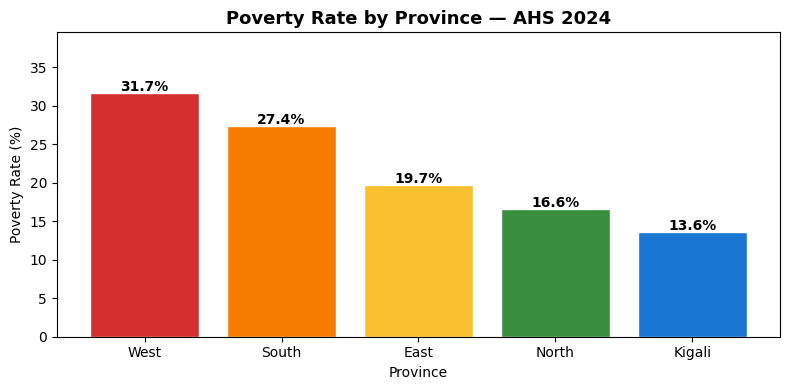

Plot saved ✓


In [100]:
# Poverty by province — final visual check
pov_prov = df.groupby('province_name')['pov_jan'].mean() * 100
pov_prov = pov_prov.dropna().sort_values(ascending=False)

print('Poverty by province:')
print(pov_prov)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2']
bars = ax.bar(pov_prov.index, pov_prov.values,
              color=colors[:len(pov_prov)], edgecolor='white')
for bar, val in zip(bars, pov_prov.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Poverty Rate by Province — AHS 2024', fontsize=13, fontweight='bold')
ax.set_xlabel('Province')
ax.set_ylabel('Poverty Rate (%)')
ax.set_ylim(0, pov_prov.max() * 1.25)
plt.tight_layout()
plt.savefig(os.path.join(OUT, '..', 'output', 'figures', 'poverty_by_province_preview.png'), dpi=150)
plt.show()
print('Plot saved ✓')

## 9. Save Merged Dataset

In [101]:
output_file = os.path.join(OUT, 'ahs2024_merged.csv')
df.to_csv(output_file, index=False)

print(f'Saved: {output_file}')
print(f'Shape: {df.shape}')
print(f'\nVariables saved:')
for col in df.columns:
    print(f'  - {col}')

Saved: ..\data\ahs2024_merged.csv
Shape: (3724, 20)

Variables saved:
  - hhid
  - clust
  - province_name
  - district_name
  - s0q14
  - s0q15
  - s0q16
  - weight
  - hh_size
  - head_sex
  - head_age
  - n_children
  - n_elderly
  - n_working
  - dep_ratio
  - quintile
  - pov_jan
  - epov_jan
  - total_agr_land
  - n_plots


## Summary

| File | Level | Key variables |
|------|-------|---------------|
| Section 0 | Household | `province_name`, `district_name`, `s0q14`, `s0q15`, `weight` |
| Section 1 | Individual → HH | `hh_size`, `head_sex`, `head_age`, `dep_ratio` |
| Section 2 | Plot → HH | `pov_jan`, `epov_jan`, `quintile`, `total_agr_land` |

**Next:** `02_variable_construction.ipynb`